# Risk metrics examples

VaR/CVaR workflow using rolling marginal models and an R-vine copula.

In [1]:
from pyscarcopula._utils import pobs
from pyscarcopula import (
    GumbelCopula, FrankCopula, JoeCopula, ClaytonCopula,
    GaussianCopula, StudentCopula, CVineCopula, RVineCopula,
    PredictConfig,
)
from pyscarcopula.api import fit, sample, predict, predictive_mean
from pyscarcopula.stattests import gof_test

import numpy as np
import pandas as pd
import time
from pathlib import Path
from matplotlib import pyplot as plt


DATA_DIR = Path('data')
if not DATA_DIR.exists():
    DATA_DIR = Path('..') / 'data'


## Read dataset

In [2]:
crypto_prices = pd.read_csv(DATA_DIR / 'crypto_prices.csv', index_col=0, sep=';')

In [3]:
tickers_6d = ['BTC-USD', 'ETH-USD', 'BNB-USD', 'ADA-USD', 'XRP-USD', 'DOGE-USD']

## 8. Risk metrics (VaR / CVaR)

In [4]:
from pyscarcopula.contrib.risk_metrics import risk_metrics

d = len(tickers_6d)
returns_6d = np.log(
    crypto_prices[tickers_6d] / crypto_prices[tickers_6d].shift(1))[501:1001]

gamma = 0.95
window_len = 250
MC_iterations = 100_000
method = 'scar-tm-ou'
marginals_method = 'johnsonsu'

risk_copula = RVineCopula()

result_rm = risk_metrics(
    risk_copula,
    returns_6d.values,
    window_len = window_len,
    gamma = gamma, N_mc = MC_iterations,
    marginals_method = marginals_method,
    method = method,
    optimize_portfolio = False,
    portfolio_weight = np.ones(d) / d,
    n_jobs = 10, # parallel computing
    # perfomance tuning
    truncation_level = 2,
)

Fitting marginals (johnsonsu)...
gamma=0.95, N_mc=100000, method=scar-tm-ou, n_jobs=10


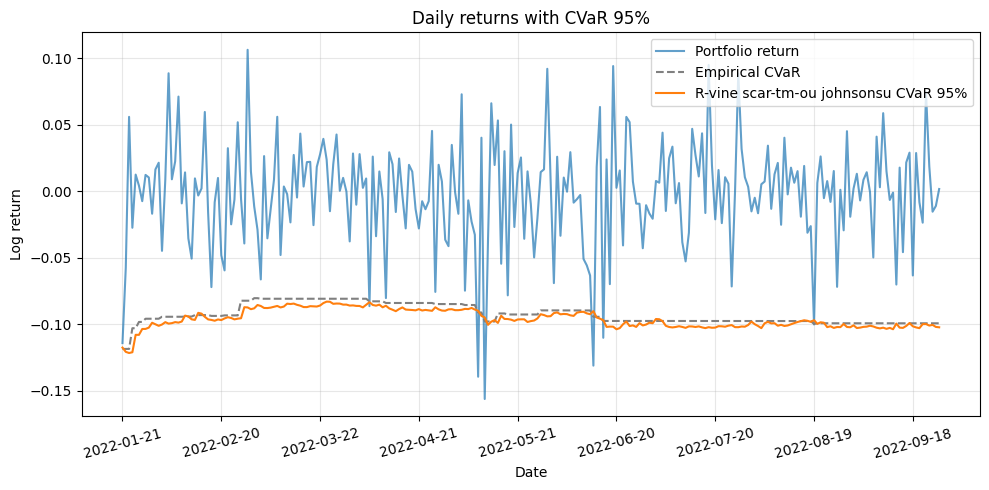

In [5]:
from matplotlib import pyplot as plt
from pyscarcopula.contrib.empirical import cvar_emp_window
import matplotlib.ticker as plticker

weight = result_rm[gamma][MC_iterations]['weight']

pd_cvar = pd.Series(
    data = -result_rm[gamma][MC_iterations]['cvar'],
    index = returns_6d.index
).shift(1)


daily_returns = ((np.exp(returns_6d) - 1) * weight).sum(axis=1)
cvar_emp = cvar_emp_window(daily_returns.values, 1 - gamma, window_len)

i1 = window_len
i2 = len(returns_6d) - 1

fig, ax = plt.subplots(figsize=(10, 5))
loc = plticker.MultipleLocator(base=30.0)

ax.plot(np.clip(daily_returns, -0.2, 0.2)[i1:i2], label='Portfolio return', alpha=0.7)
ax.plot(cvar_emp[i1:i2], label='Empirical CVaR', linestyle='dashed', color='gray')
ax.plot(pd_cvar[i1:i2], label=f'R-vine {method} {marginals_method} CVaR 95%')

ax.set_title('Daily returns with CVaR 95%')
ax.xaxis.set_major_locator(loc)
ax.set_xlabel('Date')
ax.set_ylabel('Log return')
ax.tick_params(axis='x', labelrotation=15)
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()